<h1>Dataset Linkedin Job Postings</h1>

<h3>Mempersiapkan Library</h3>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


<h1>Gathering data</h1>

In [2]:
base_path = "dataset"
print("--- Menghubungkan dan membaca dataset ----- ")
df_postings = pd.read_csv(os.path.join(base_path,"mappings","postings.csv"))

#Folder Companies
df_companies = pd.read_csv(os.path.join(base_path,"companies","companies.csv"))
df_company_industries = pd.read_csv(os.path.join(base_path,"companies","company_industries.csv"))
df_company_specialities = pd.read_csv(os.path.join(base_path,"companies","company_specialities.csv"))
df_employee_counts = pd.read_csv(os.path.join(base_path,"companies","employee_counts.csv"))

#Folder jobs
df_benefits = pd.read_csv(os.path.join(base_path,"jobs","benefits.csv"))
df_jobs_industries = pd.read_csv(os.path.join(base_path,"jobs","job_industries.csv"))
df_jobs_skills = pd.read_csv(os.path.join(base_path,"jobs","job_skills.csv"))
df_salaries = pd.read_csv(os.path.join(base_path,"jobs","salaries.csv"))

--- Menghubungkan dan membaca dataset ----- 


In [3]:
# 2. ASSESSING DATA
print("=== Info Data Postings ===")
print(df_postings.info())

print("\n=== Jumlah Missing Values ===")
print(df_postings.isnull().sum()[df_postings.isnull().sum() > 0])

print("\n=== Jumlah Duplikasi Data ===")
print(f"Duplikasi: {df_postings.duplicated().sum()}")

=== Info Data Postings ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  object 
 2   title                       123849 non-null  object 
 3   description                 123842 non-null  object 
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   object 
 6   location                    123849 non-null  object 
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  object 
 12  applies                     23320 non-null   

<h1>3. Assesing data pendukung (Companies atau Jobs)</h1>

In [4]:
dataframes = {
    "Companies": df_companies,
    "Company Industries" : df_company_industries,
    "Company Specialities" : df_company_specialities,
    "Employee Counts" : df_employee_counts,
    "Benefits" : df_benefits,
    "Jobs Industries" : df_jobs_industries,
    "Jobs Skills" : df_jobs_skills,
    "Salaries" : df_salaries
}

print("==== Pengecheckan data tambahan ===")
for name,df in dataframes.items():
    print(f"\n Tabel: {name}")
    print(f" - Ukuran Baris & Kolom {df.shape}")
    print(f" - Jumlah duplikasi {df.duplicated().sum()}")

#Memeriksa missing value pada dataset
    missing = df.isnull().sum()
    missing_cols = missing[missing > 0]
    if not missing_cols.empty:
        print(" - Missing Values:")
        for col,val in missing_cols.items():
            print(f"  *{col}: {val} baris")
    else:
        print(" - Missing Values : Bersih(0)")
    print("-" * 40)

==== Pengecheckan data tambahan ===

 Tabel: Companies
 - Ukuran Baris & Kolom (24473, 10)
 - Jumlah duplikasi 0
 - Missing Values:
  *name: 1 baris
  *description: 297 baris
  *company_size: 2774 baris
  *state: 22 baris
  *city: 1 baris
  *zip_code: 28 baris
  *address: 22 baris
----------------------------------------

 Tabel: Company Industries
 - Ukuran Baris & Kolom (24375, 2)
 - Jumlah duplikasi 0
 - Missing Values : Bersih(0)
----------------------------------------

 Tabel: Company Specialities
 - Ukuran Baris & Kolom (169387, 2)
 - Jumlah duplikasi 0
 - Missing Values : Bersih(0)
----------------------------------------

 Tabel: Employee Counts
 - Ukuran Baris & Kolom (35787, 4)
 - Jumlah duplikasi 0
 - Missing Values : Bersih(0)
----------------------------------------

 Tabel: Benefits
 - Ukuran Baris & Kolom (67943, 3)
 - Jumlah duplikasi 0
 - Missing Values : Bersih(0)
----------------------------------------

 Tabel: Jobs Industries
 - Ukuran Baris & Kolom (164808, 2)
 -

<h1>3. Cleaning And Merging Data</h1>

In [5]:
# 3. CLEANING & MERGING DATA

# Langkah A: Memperbaiki med_salary di df_salaries menggunakan min & max
print("Mengisi med_salary yang kosong di df_salaries...")
df_salaries['med_salary'] = df_salaries['med_salary'].fillna((df_salaries['min_salary'] + df_salaries['max_salary']) / 2)

# Langkah B: Merge df_postings dengan df_salaries (berdasarkan job_id)
# Kita gunakan left join agar lowongan yang tidak mencantumkan gaji tetap aman di dataframe utama
df_market = pd.merge(df_postings, df_salaries[['job_id', 'min_salary', 'max_salary', 'med_salary', 'pay_period', 'currency']], 
                     on='job_id', 
                     how='left', 
                     suffixes=('_postings', '_salaries'))

# Sinkronisasi kolom gaji: Jika di postings kosong, isi dari tabel salaries
df_market['med_salary'] = df_market['med_salary_postings'].fillna(df_market['med_salary_salaries'])
df_market['min_salary'] = df_market['min_salary_postings'].fillna(df_market['min_salary_salaries'])
df_market['max_salary'] = df_market['max_salary_postings'].fillna(df_market['max_salary_salaries'])

# Drop kolom duplikat hasil suffix merge yang sudah tidak dipakai
df_market.drop(columns=['med_salary_postings', 'med_salary_salaries', 
                        'min_salary_postings', 'min_salary_salaries', 
                        'max_salary_postings', 'max_salary_salaries'], inplace=True)

# Langkah C: Handling missing value untuk remote_allowed (NaN dianggap Non-Remote / 0)
df_market['remote_allowed'] = df_market['remote_allowed'].fillna(0)

print(f"Proses merging awal selesai! Ukuran dataset gabungan sekarang: {df_market.shape}")
print(f"Data gaji terselamatkan (med_salary tidak kosong): {df_market['med_salary'].notnull().sum()} baris")

Mengisi med_salary yang kosong di df_salaries...
Proses merging awal selesai! Ukuran dataset gabungan sekarang: (123849, 33)
Data gaji terselamatkan (med_salary tidak kosong): 36073 baris


<h1>Langkah 4: Eksplorasi Hubungan Skill & Industri (Finalisasi Data Prep)</h1>

In [6]:
# Langkah D: Cleaning df_companies & df_company_industries
print("Membersihkan data perusahaan...")
df_companies['company_size'] = df_companies['company_size'].fillna('Unknown')

# Gabungkan profil perusahaan dengan industrinya
df_company_profile = pd.merge(df_companies[['company_id', 'name', 'company_size', 'country', 'city']], 
                              df_company_industries, 
                              on='company_id', 
                              how='left')

df_company_profile['industry'] = df_company_profile['industry'].fillna('Unknown')
print(f"Data profil perusahaan siap! Ukuran: {df_company_profile.shape}")

Membersihkan data perusahaan...
Data profil perusahaan siap! Ukuran: (24483, 6)


<h1>4. Exploratory Data Analysis</h1>

=== Distribusi Lowongan Kerja: Remote vs Non-Remote ===
Jumlah Non-Remote (0.0) dan Remote (1.0):
remote_allowed
0.0    108603
1.0     15246
Name: count, dtype: int64

Persentase:
remote_allowed
0.0    87.689848
1.0    12.310152
Name: proportion, dtype: float64



C:\Users\Nashril Fikri\AppData\Local\Temp\ipykernel_30440\1708981760.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='remote_allowed', data=df_market, palette='Set2')


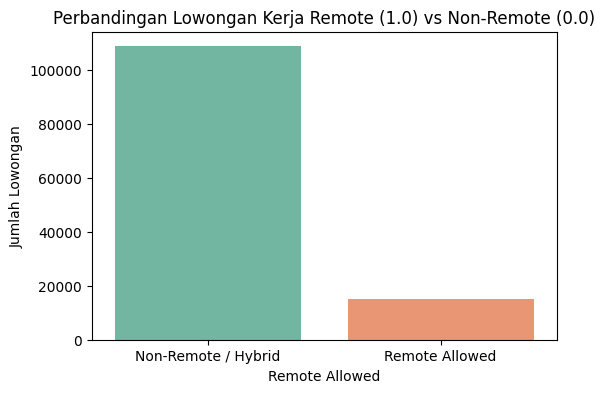

In [7]:
# 4. EXPLORATORY DATA ANALYSIS (EDA) - Q1
print("=== Distribusi Lowongan Kerja: Remote vs Non-Remote ===")
remote_counts = df_market['remote_allowed'].value_counts()
remote_pct = df_market['remote_allowed'].value_counts(normalize=True) * 100

print(f"Jumlah Non-Remote (0.0) dan Remote (1.0):\n{remote_counts}\n")
print(f"Persentase:\n{remote_pct}\n")

# Visualisasi Sederhana
plt.figure(figsize=(6, 4))
sns.countplot(x='remote_allowed', data=df_market, palette='Set2')
plt.title('Perbandingan Lowongan Kerja Remote (1.0) vs Non-Remote (0.0)')
plt.xlabel('Remote Allowed')
plt.ylabel('Jumlah Lowongan')
plt.xticks([0, 1], ['Non-Remote / Hybrid', 'Remote Allowed'])
plt.show()

<h1># 5. EXPLORATORY DATA ANALYSIS (EDA) - Q2 (Distribusi Gaji)</h1>

=== Statistik Deskriptif Gaji (Dalam Dataset asli) ===
count    3.607300e+04
mean     6.860472e+04
std      5.445734e+05
min      0.000000e+00
25%      3.000000e+01
50%      5.825000e+04
75%      1.100000e+05
max      1.025000e+08
Name: med_salary, dtype: float64


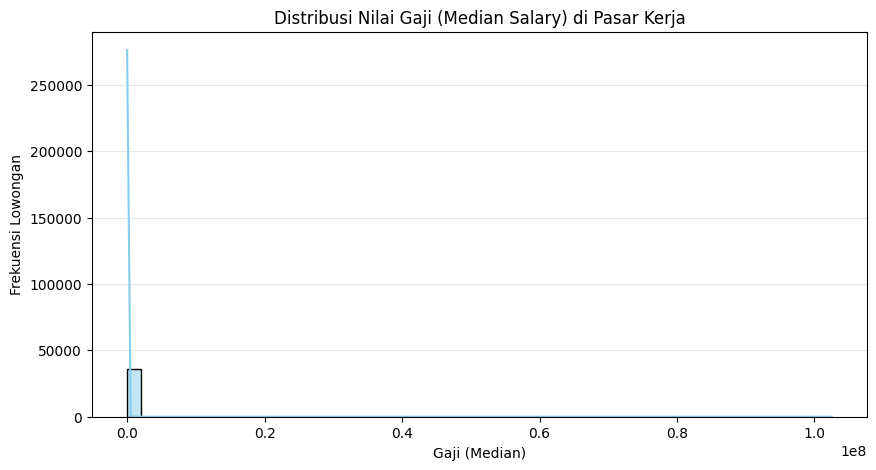

In [8]:
# 5. EXPLORATORY DATA ANALYSIS (EDA) - Q2 (Distribusi Gaji)
print("=== Statistik Deskriptif Gaji (Dalam Dataset asli) ===")
print(df_market['med_salary'].describe())

# Visualisasi Distribusi Gaji
plt.figure(figsize=(10, 5))
sns.histplot(df_market['med_salary'].dropna(), bins=50, kde=True, color='skyblue')
plt.title('Distribusi Nilai Gaji (Median Salary) di Pasar Kerja')
plt.xlabel('Gaji (Median)')
plt.ylabel('Frekuensi Lowongan')
plt.grid(axis='y', alpha=0.3)
plt.show()

<h1>Standardisasi & Penyaringan Data Gaji</h1>

In [9]:
# Cek daftar nama kolom yang ada di df_market saat ini
print(df_market.columns.tolist())

['job_id', 'company_name', 'title', 'description', 'pay_period_postings', 'location', 'company_id', 'views', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency_postings', 'compensation_type', 'normalized_salary', 'zip_code', 'fips', 'pay_period_salaries', 'currency_salaries', 'med_salary', 'min_salary', 'max_salary']


In [10]:
# Menyatukan kolom pay_period dan currency hasil merge
df_market['pay_period'] = df_market['pay_period_postings'].fillna(df_market['pay_period_salaries'])
df_market['currency'] = df_market['currency_postings'].fillna(df_market['currency_salaries'])

# Hapus kolom pecahan suffix yang sudah tidak dipakai agar dataframe rapi kembali
df_market.drop(columns=['pay_period_postings', 'pay_period_salaries', 
                        'currency_postings', 'currency_salaries'], inplace=True)

# Sekarang jalankan kembali pengecekan sebaran data tipe periode pembayaran dan mata uang
print("=== Sebaran Tipe Pay Period (Setelah Disatukan) ===")
print(df_market['pay_period'].value_counts(dropna=False))

print("\n=== Sebaran Mata Uang / Currency (Setelah Disatukan) ===")
print(df_market['currency'].value_counts(dropna=False))

=== Sebaran Tipe Pay Period (Setelah Disatukan) ===
pay_period
NaN         87776
YEARLY      20628
HOURLY      14741
MONTHLY       518
WEEKLY        177
BIWEEKLY        9
Name: count, dtype: int64

=== Sebaran Mata Uang / Currency (Setelah Disatukan) ===
currency
NaN    87776
USD    36058
EUR        6
CAD        3
BBD        2
AUD        2
GBP        2
Name: count, dtype: int64


In [11]:
# ==========================================
# RE-CLEANING & INTEGRATED MERGING DATA
# ==========================================

print("1. Memperbaiki med_salary langsung di df_salaries...")
df_salaries['med_salary'] = df_salaries['med_salary'].fillna((df_salaries['min_salary'] + df_salaries['max_salary']) / 2)

print("2. Membangun ulang df_market dengan left join yang presisi...")
df_market = pd.merge(
    df_postings, 
    df_salaries[['job_id', 'min_salary', 'max_salary', 'med_salary', 'pay_period', 'currency']], 
    on='job_id', 
    how='left', 
    suffixes=('_postings', '_salaries')
)

print("3. Sinkronisasi kolom gaji (Postings & Salaries)...")
df_market['med_salary'] = df_market['med_salary_postings'].fillna(df_market['med_salary_salaries'])
df_market['min_salary'] = df_market['min_salary_postings'].fillna(df_market['min_salary_salaries'])
df_market['max_salary'] = df_market['max_salary_postings'].fillna(df_market['max_salary_salaries'])

print("4. Menyatukan kolom pay_period dan currency...")
df_market['pay_period'] = df_market['pay_period_postings'].fillna(df_market['pay_period_salaries'])
df_market['currency'] = df_market['currency_postings'].fillna(df_market['currency_salaries'])

# List kolom pecahan lama yang aman untuk di-drop
cols_to_drop = [
    'med_salary_postings', 'med_salary_salaries', 
    'min_salary_postings', 'min_salary_salaries', 
    'max_salary_postings', 'max_salary_salaries',
    'pay_period_postings', 'pay_period_salaries', 
    'currency_postings', 'currency_salaries'
]

print("5. Membersihkan kolom-kolom pecahan duplikat...")
df_market.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Langkah C tambahan: Handling missing value untuk remote_allowed
df_market['remote_allowed'] = df_market['remote_allowed'].fillna(0)

print("\n✅ PROSES SELESAI TANPA ERROR!")
print(f"Ukuran Dataset Baru: {df_market.shape}")
print("-" * 50)

# Menampilkan Ringkasan Data Target Kita
print("=== Sebaran Tipe Pay Period (Setelah Disatukan) ===")
print(df_market['pay_period'].value_counts(dropna=False))

print("\n=== Sebaran Mata Uang / Currency (Setelah Disatukan) ===")
print(df_market['currency'].value_counts(dropna=False))

1. Memperbaiki med_salary langsung di df_salaries...
2. Membangun ulang df_market dengan left join yang presisi...
3. Sinkronisasi kolom gaji (Postings & Salaries)...
4. Menyatukan kolom pay_period dan currency...
5. Membersihkan kolom-kolom pecahan duplikat...

✅ PROSES SELESAI TANPA ERROR!
Ukuran Dataset Baru: (123849, 31)
--------------------------------------------------
=== Sebaran Tipe Pay Period (Setelah Disatukan) ===
pay_period
NaN         87776
YEARLY      20628
HOURLY      14741
MONTHLY       518
WEEKLY        177
BIWEEKLY        9
Name: count, dtype: int64

=== Sebaran Mata Uang / Currency (Setelah Disatukan) ===
currency
NaN    87776
USD    36058
EUR        6
CAD        3
BBD        2
AUD        2
GBP        2
Name: count, dtype: int64


In [12]:
# =======================================================
# STANDARDISASI GAJI MENJADI BULANAN (MONTHLY)
# =======================================================

def convert_to_monthly(row):
    salary = row['med_salary']
    period = row['pay_period']
    
    if pd.isnull(salary) or pd.isnull(period):
        return np.nan
    
    # Rumus Konversi ke Bulanan
    if period == 'YEARLY':
        return salary / 12
    elif period == 'HOURLY':
        return salary * 160  # 40 jam/minggu * 4 minggu
    elif period == 'WEEKLY':
        return salary * 4
    elif period == 'BIWEEKLY':
        return salary * 2
    elif period == 'MONTHLY':
        return salary
    else:
        return np.nan

print("Menghitung ulang gaji ke basis Bulanan (Monthly)...")
df_market['monthly_salary_usd'] = df_market.apply(convert_to_monthly, axis=1)

# Filter hanya untuk mata uang USD yang valid dan gajinya di atas 0 (membuang noise)
df_salary_clean = df_market[(df_market['currency'] == 'USD') & (df_market['monthly_salary_usd'] > 0)].copy()

print(f"Standardisasi selesai!")
print(f"Jumlah data gaji USD bulanan yang siap dianalisis: {df_salary_clean.shape[0]} baris")
print("\nStatistik Deskriptif Baru (Gaji Bulanan dalam USD):")
print(df_salary_clean['monthly_salary_usd'].describe())

Menghitung ulang gaji ke basis Bulanan (Monthly)...


Standardisasi selesai!
Jumlah data gaji USD bulanan yang siap dianalisis: 36044 baris

Statistik Deskriptif Baru (Gaji Bulanan dalam USD):
count    3.604400e+04
mean     1.625005e+04
std      3.926593e+05
min      8.333333e-02
25%      4.080000e+03
50%      6.666667e+03
75%      1.016667e+04
max      4.120000e+07
Name: monthly_salary_usd, dtype: float64


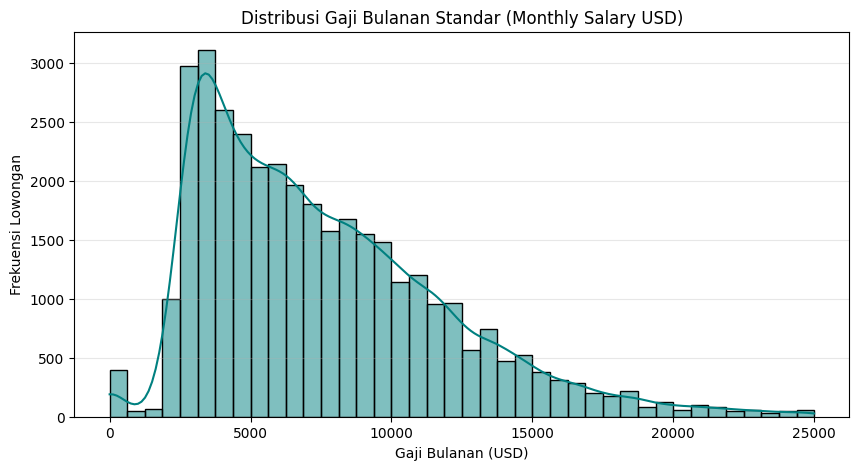

In [13]:
plt.figure(figsize=(10, 5))
# Kita batasi plot menggunakan Q3 + 1.5*IQR atau nilai tertentu (misal max $25,000/month) agar tidak ditarik outlier ekstrem
sns.histplot(df_salary_clean[df_salary_clean['monthly_salary_usd'] <= 25000]['monthly_salary_usd'], bins=40, kde=True, color='teal')
plt.title('Distribusi Gaji Bulanan Standar (Monthly Salary USD)')
plt.xlabel('Gaji Bulanan (USD)')
plt.ylabel('Frekuensi Lowongan')
plt.grid(axis='y', alpha=0.3)
plt.show()

Menghubungkan data lowongan dengan daftar skill...

=== 15 Skill Paling Sering Diminta di Pasar Kerja ===
skill_abr
IT      7170
SALE    5638
MGMT    5489
MNFC    4660
HCPR    3775
ENG     3774
OTHR    3411
BD      3380
FIN     2935
ACCT    2306
ADM     1920
MRKT    1641
PRJM    1441
ANLS    1265
CUST    1164
Name: count, dtype: int64


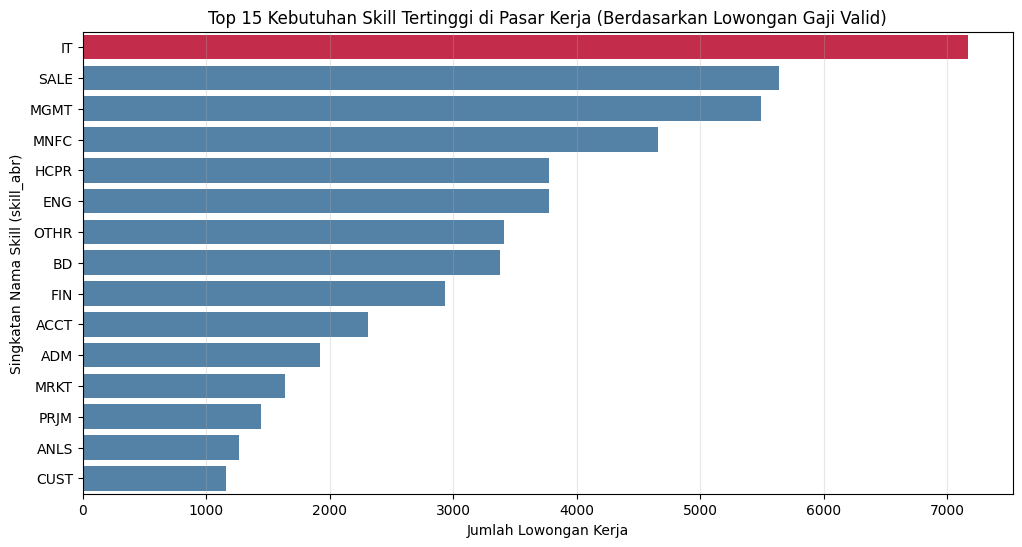

In [14]:
# 6. EXPLORATORY DATA ANALYSIS (EDA) - Q3 (Top Demanded Skills)

print("Menghubungkan data lowongan dengan daftar skill...")
# Merge data gaji bersih dengan tabel skill berdasarkan job_id
df_skills_market = pd.merge(
    df_salary_clean[['job_id', 'monthly_salary_usd']], 
    df_jobs_skills, 
    on='job_id', 
    how='inner'
)

# Hitung 15 skill yang paling sering muncul
top_skills = df_skills_market['skill_abr'].value_counts().head(15)

print("\n=== 15 Skill Paling Sering Diminta di Pasar Kerja ===")
print(top_skills)

# --- MODIFIKASI WARNA DINAMIS ---
# Batang pertama (tertinggi) diberi warna merah ('crimson'), sisanya diberi warna biru ('steelblue')
custom_colors = ['crimson' if i == 0 else 'steelblue' for i in range(len(top_skills))]

# Visualisasi Top Skills
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_skills.values, 
    y=top_skills.index, 
    palette=custom_colors,  # Menggunakan list warna yang kita buat
    hue=top_skills.index, 
    legend=False
)
plt.title('Top 15 Kebutuhan Skill Tertinggi di Pasar Kerja (Berdasarkan Lowongan Gaji Valid)')
plt.xlabel('Jumlah Lowongan Kerja')
plt.ylabel('Singkatan Nama Skill (skill_abr)')
plt.grid(axis='x', alpha=0.3)
plt.show()

## Analisis Salary Breakdown per Industri & Experience Level

In [20]:
# Konversi listed_time & normalisasi gaji ke monthly USD
conversion = {'HOURLY': 160, 'DAILY': 22, 'WEEKLY': 4.33, 'MONTHLY': 1, 'YEARLY': 1/12}

pay_col = [col for col in df_market.columns if 'pay_period' in col.lower()][0]
print(f"Kolom pay_period ditemukan: {pay_col}")

df_salary_clean = df_market[df_market['med_salary'].notnull()].copy()
df_salary_clean['pay_period_clean'] = df_salary_clean[pay_col].str.upper().str.strip()
df_salary_clean['multiplier'] = df_salary_clean['pay_period_clean'].map(conversion)
df_salary_clean = df_salary_clean[df_salary_clean['multiplier'].notnull()]
df_salary_clean['monthly_salary_usd'] = df_salary_clean['med_salary'] * df_salary_clean['multiplier']

# Filter outlier (gaji masuk akal: $500 - $50.000/bulan)
df_salary_clean = df_salary_clean[
    (df_salary_clean['monthly_salary_usd'] >= 500) & 
    (df_salary_clean['monthly_salary_usd'] <= 50000)
]
print(f"Data gaji bersih: {len(df_salary_clean)} baris")

Kolom pay_period ditemukan: pay_period
Data gaji bersih: 35597 baris


In [21]:
# A1: Mapping nama industri lewat company_id
df_job_company = df_salary_clean[['job_id', 'company_id', 'monthly_salary_usd']].dropna(subset=['company_id']).copy()
df_job_company['company_id'] = df_job_company['company_id'].astype(int)

df_salary_named = pd.merge(
    df_job_company,
    df_company_industries[['company_id', 'industry']],
    on='company_id',
    how='inner'
)

print(f"Data tergabung: {len(df_salary_named)} baris")
print(f"Jumlah industri unik: {df_salary_named['industry'].nunique()}")

Data tergabung: 35113 baris
Jumlah industri unik: 139


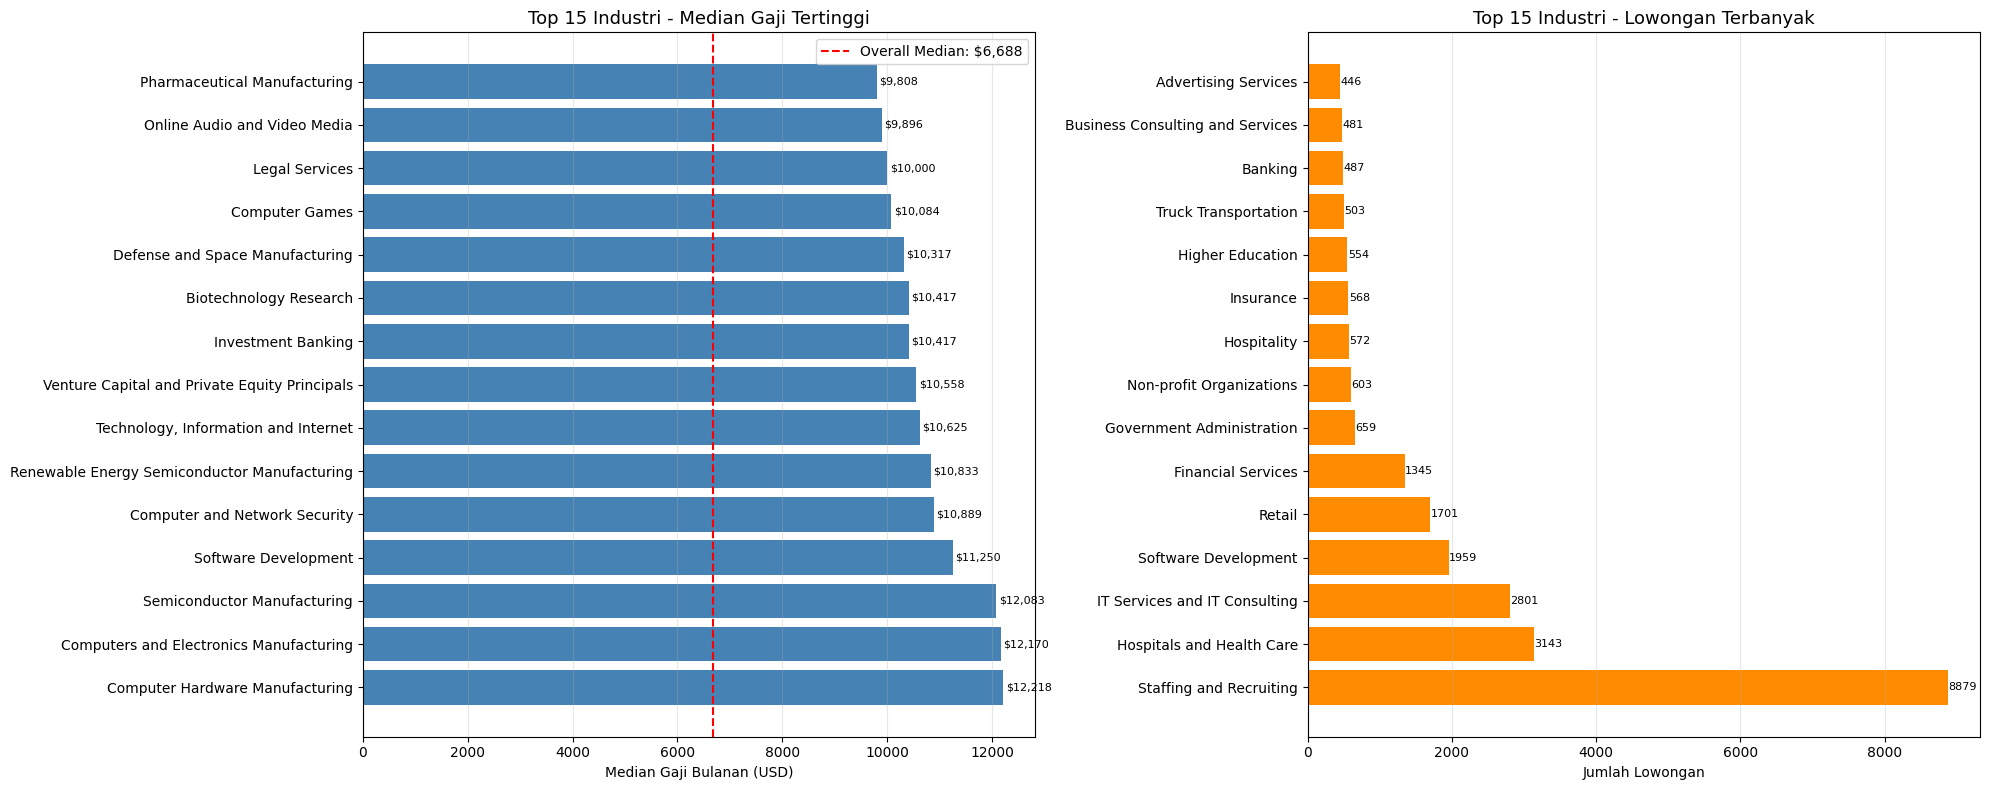


=== Top 10 Industri (Median Gaji Tertinggi, min. 10 lowongan) ===
                                     industry  median_salary  count
              Computer Hardware Manufacturing   12218.229167     30
      Computers and Electronics Manufacturing   12170.416667     40
                  Semiconductor Manufacturing   12083.333333     86
                         Software Development   11250.000000   1959
                Computer and Network Security   10888.888750    109
 Renewable Energy Semiconductor Manufacturing   10833.333333     97
         Technology, Information and Internet   10625.000000     89
Venture Capital and Private Equity Principals   10558.333333     14
                           Investment Banking   10416.666667     11
                       Biotechnology Research   10416.666667    312


In [22]:
# A1: Visualisasi Gaji per Industri
industry_stats = df_salary_named.groupby('industry')['monthly_salary_usd'].agg(
    median_salary='median',
    count='count'
).reset_index()

top_by_salary = industry_stats[industry_stats['count'] >= 10].sort_values('median_salary', ascending=False).head(15)
top_by_count  = industry_stats.sort_values('count', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

bars = axes[0].barh(top_by_salary['industry'], top_by_salary['median_salary'], color='steelblue')
axes[0].set_title('Top 15 Industri - Median Gaji Tertinggi', fontsize=13)
axes[0].set_xlabel('Median Gaji Bulanan (USD)')
axes[0].axvline(df_salary_named['monthly_salary_usd'].median(), color='red', linestyle='--',
                label=f'Overall Median: ${df_salary_named["monthly_salary_usd"].median():,.0f}')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)
for bar, val in zip(bars, top_by_salary['median_salary']):
    axes[0].text(val + 50, bar.get_y() + bar.get_height()/2, f'${val:,.0f}', va='center', fontsize=8)

bars2 = axes[1].barh(top_by_count['industry'], top_by_count['count'], color='darkorange')
axes[1].set_title('Top 15 Industri - Lowongan Terbanyak', fontsize=13)
axes[1].set_xlabel('Jumlah Lowongan')
axes[1].grid(axis='x', alpha=0.3)
for bar, val in zip(bars2, top_by_count['count']):
    axes[1].text(val + 5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("\n=== Top 10 Industri (Median Gaji Tertinggi, min. 10 lowongan) ===")
print(top_by_salary[['industry', 'median_salary', 'count']].head(10).to_string(index=False))

C:\Users\Nashril Fikri\AppData\Local\Temp\ipykernel_30440\1209077279.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(exp_data, labels=exp_labels, patch_artist=True, vert=True)
C:\Users\Nashril Fikri\AppData\Local\Temp\ipykernel_30440\1209077279.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(exp_stats.index, rotation=20, ha='right')


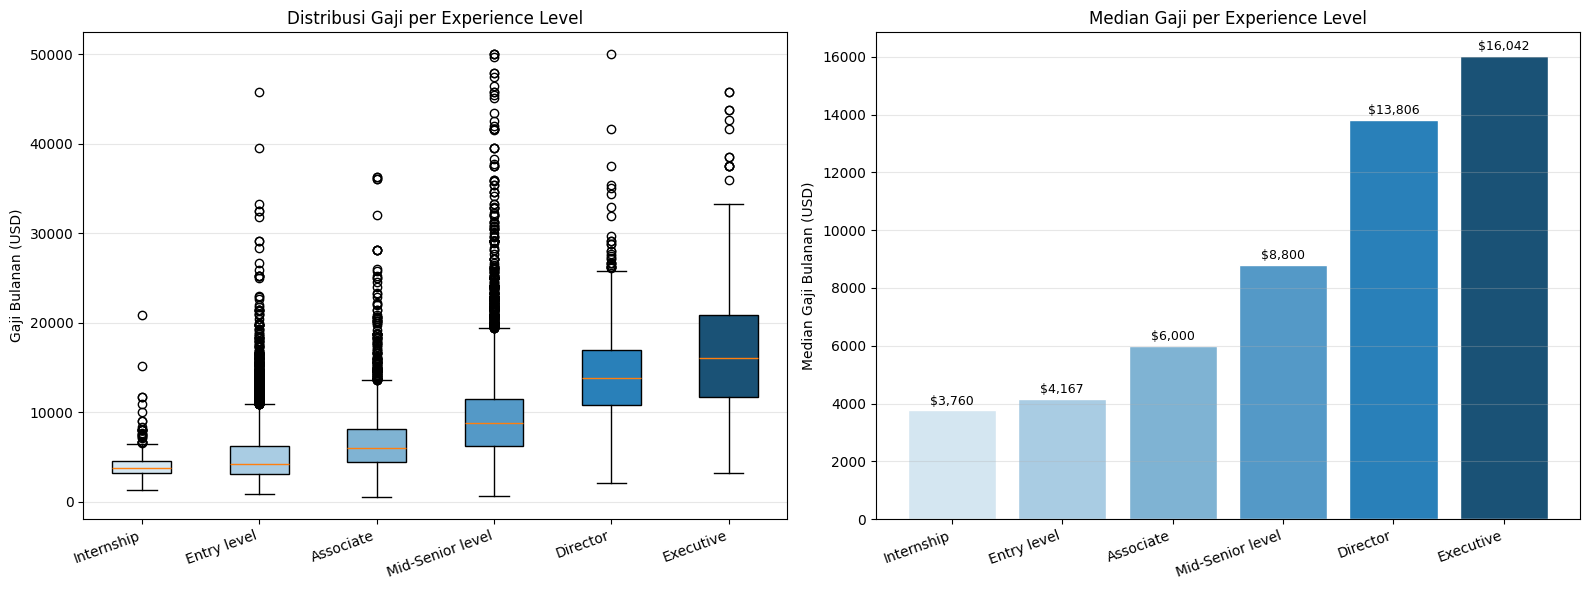


=== Statistik Gaji per Experience Level ===
                              median      mean      std  count
formatted_experience_level                                    
Internship                   3760.00   4155.77  1798.14    363
Entry level                  4166.67   5219.22  3142.35   9037
Associate                    6000.00   6737.98  3393.54   3808
Mid-Senior level             8800.00   9272.39  4581.19  12741
Director                    13806.25  14204.42  5041.06   1260
Executive                   16041.67  16698.59  7978.38    380


In [23]:
# Bersihkan kolom experience level
df_salary_exp = df_salary_clean[df_salary_clean['formatted_experience_level'].notnull()].copy()

exp_order = ['Internship', 'Entry level', 'Associate', 'Mid-Senior level', 'Director', 'Executive']

exp_stats = df_salary_exp.groupby('formatted_experience_level')['monthly_salary_usd'].agg(
    ['median', 'mean', 'std', 'count']
).reindex(exp_order).dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot kiri: Boxplot distribusi gaji per level
exp_data = [df_salary_exp[df_salary_exp['formatted_experience_level'] == lvl]['monthly_salary_usd'].values 
            for lvl in exp_order if lvl in df_salary_exp['formatted_experience_level'].unique()]
exp_labels = [lvl for lvl in exp_order if lvl in df_salary_exp['formatted_experience_level'].unique()]

bp = axes[0].boxplot(exp_data, labels=exp_labels, patch_artist=True, vert=True)
colors = ['#d4e6f1', '#a9cce3', '#7fb3d3', '#5499c7', '#2980b9', '#1a5276']
for patch, color in zip(bp['boxes'], colors[:len(exp_data)]):
    patch.set_facecolor(color)
axes[0].set_title('Distribusi Gaji per Experience Level')
axes[0].set_ylabel('Gaji Bulanan (USD)')
axes[0].set_xticklabels(exp_labels, rotation=20, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# Plot kanan: Median gaji per level (bar)
axes[1].bar(exp_stats.index, exp_stats['median'], color=colors[:len(exp_stats)], edgecolor='white')
for i, (idx, row) in enumerate(exp_stats.iterrows()):
    axes[1].text(i, row['median'] + 100, f"${row['median']:,.0f}", ha='center', va='bottom', fontsize=9)
axes[1].set_title('Median Gaji per Experience Level')
axes[1].set_ylabel('Median Gaji Bulanan (USD)')
axes[1].set_xticklabels(exp_stats.index, rotation=20, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Statistik Gaji per Experience Level ===")
print(exp_stats.round(2).to_string())

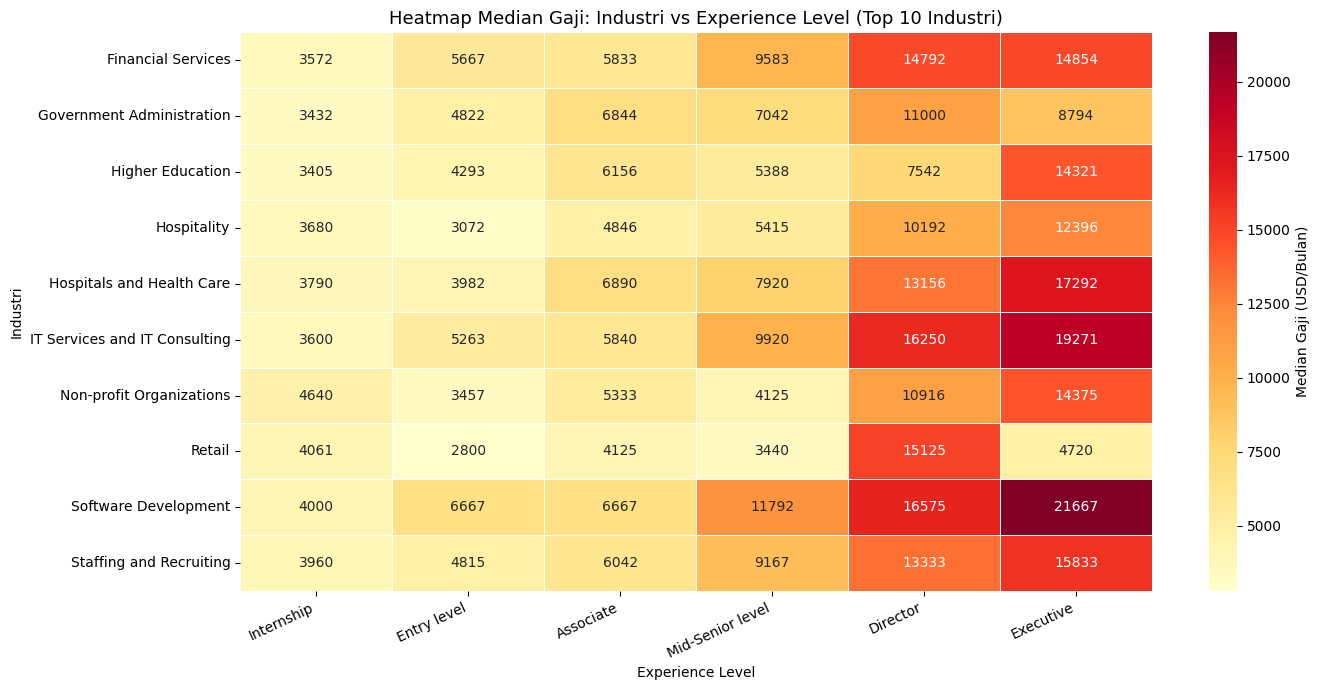

In [25]:
# A2: Heatmap Industri vs Experience Level
df_combined_named = pd.merge(
    df_salary_clean[['job_id', 'company_id', 'monthly_salary_usd', 'formatted_experience_level']].dropna(),
    df_company_industries[['company_id', 'industry']],
    on='company_id',
    how='inner'
)
df_combined_named['company_id'] = df_combined_named['company_id'].astype(int)

top10_ind = df_combined_named['industry'].value_counts().head(10).index
df_heatmap = df_combined_named[df_combined_named['industry'].isin(top10_ind)]

pivot = df_heatmap.pivot_table(
    values='monthly_salary_usd',
    index='industry',
    columns='formatted_experience_level',
    aggfunc='median'
)
col_order = [c for c in ['Internship', 'Entry level', 'Associate', 'Mid-Senior level', 'Director', 'Executive'] if c in pivot.columns]
pivot = pivot[col_order].dropna(how='all')

plt.figure(figsize=(14, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Median Gaji (USD/Bulan)'})
plt.title('Heatmap Median Gaji: Industri vs Experience Level (Top 10 Industri)', fontsize=13)
plt.xlabel('Experience Level')
plt.ylabel('Industri')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## Analisis Peluang Pasar

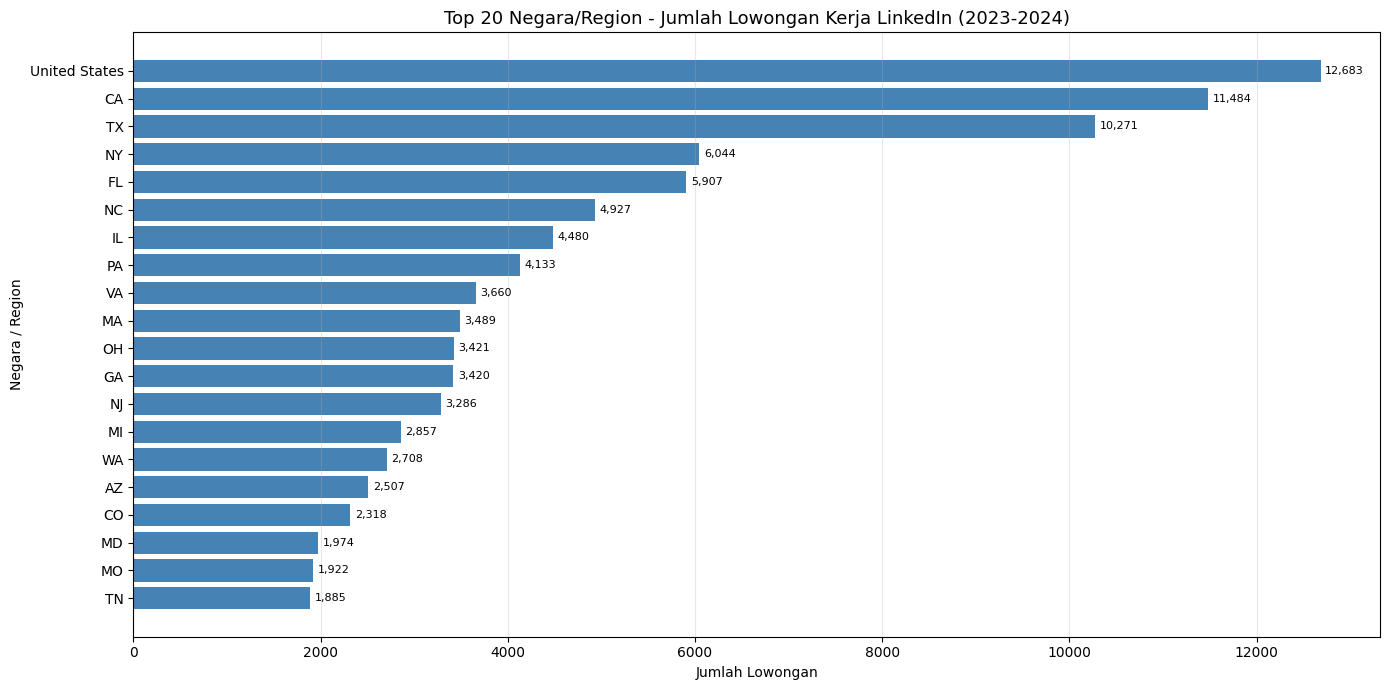

In [30]:
# Distribusi Lowongan Kerja Global (per Negara)

# Ekstrak negara dari kolom location (format biasanya "City, State" atau "City, Country")
df_location = df_market[df_market['location'].notnull()].copy()
df_location['country'] = df_location['location'].str.split(',').str[-1].str.strip()

# Ambil top 20 negara/region terbanyak
top_countries = df_location['country'].value_counts().head(20)
top_countries_sorted = top_countries.sort_values(ascending=True)  # ascending biar terbesar di atas

plt.figure(figsize=(14, 7))
bars = plt.barh(top_countries_sorted.index, top_countries_sorted.values, color='steelblue')
plt.title('Top 20 Negara/Region - Jumlah Lowongan Kerja LinkedIn (2023-2024)', fontsize=13)
plt.xlabel('Jumlah Lowongan')
plt.ylabel('Negara / Region')
for bar in bars:
    val = bar.get_width()
    plt.text(val + 50, bar.get_y() + bar.get_height()/2, f'{int(val):,}', va='center', fontsize=8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

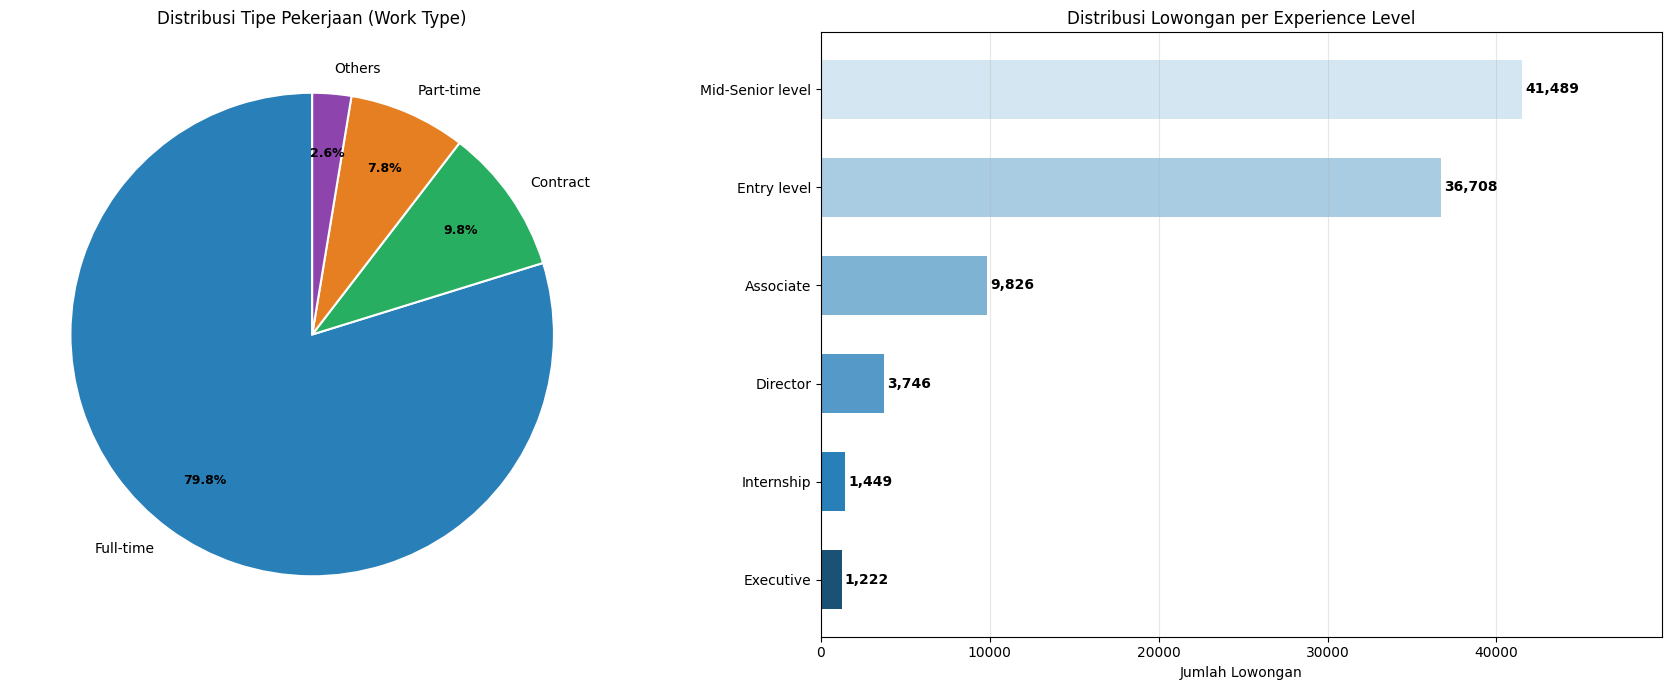

In [31]:
# Komposisi Tipe Pekerjaan & Experience Level
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot kiri: Work Type - gabung kategori kecil jadi "Others"
work_type_counts = df_market['formatted_work_type'].value_counts()
threshold = work_type_counts.sum() * 0.02  # kategori < 2% digabung
main = work_type_counts[work_type_counts >= threshold]
others_val = work_type_counts[work_type_counts < threshold].sum()
if others_val > 0:
    main['Others'] = others_val

colors_wt = ['#2980b9', '#27ae60', '#e67e22', '#8e44ad', '#c0392b', '#7f8c8d']
wedges, texts, autotexts = axes[0].pie(
    main.values, labels=main.index, autopct='%1.1f%%',
    colors=colors_wt[:len(main)], startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    pctdistance=0.75
)
for text in texts:
    text.set_fontsize(10)
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')
axes[0].set_title('Distribusi Tipe Pekerjaan (Work Type)', fontsize=12)

# Plot kanan: Experience Level - perbesar & label lebih jelas
exp_counts = df_market['formatted_experience_level'].value_counts().dropna().sort_values(ascending=True)
colors_exp = ['#1a5276', '#2980b9', '#5499c7', '#7fb3d3', '#a9cce3', '#d4e6f1']
bars2 = axes[1].barh(exp_counts.index, exp_counts.values, 
                      color=colors_exp[:len(exp_counts)], height=0.6)
axes[1].set_title('Distribusi Lowongan per Experience Level', fontsize=12)
axes[1].set_xlabel('Jumlah Lowongan')
axes[1].grid(axis='x', alpha=0.3)
axes[1].set_xlim(0, exp_counts.max() * 1.2)  # kasih ruang label
for bar in bars2:
    val = bar.get_width()
    axes[1].text(val + 200, bar.get_y() + bar.get_height()/2, 
                 f'{int(val):,}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

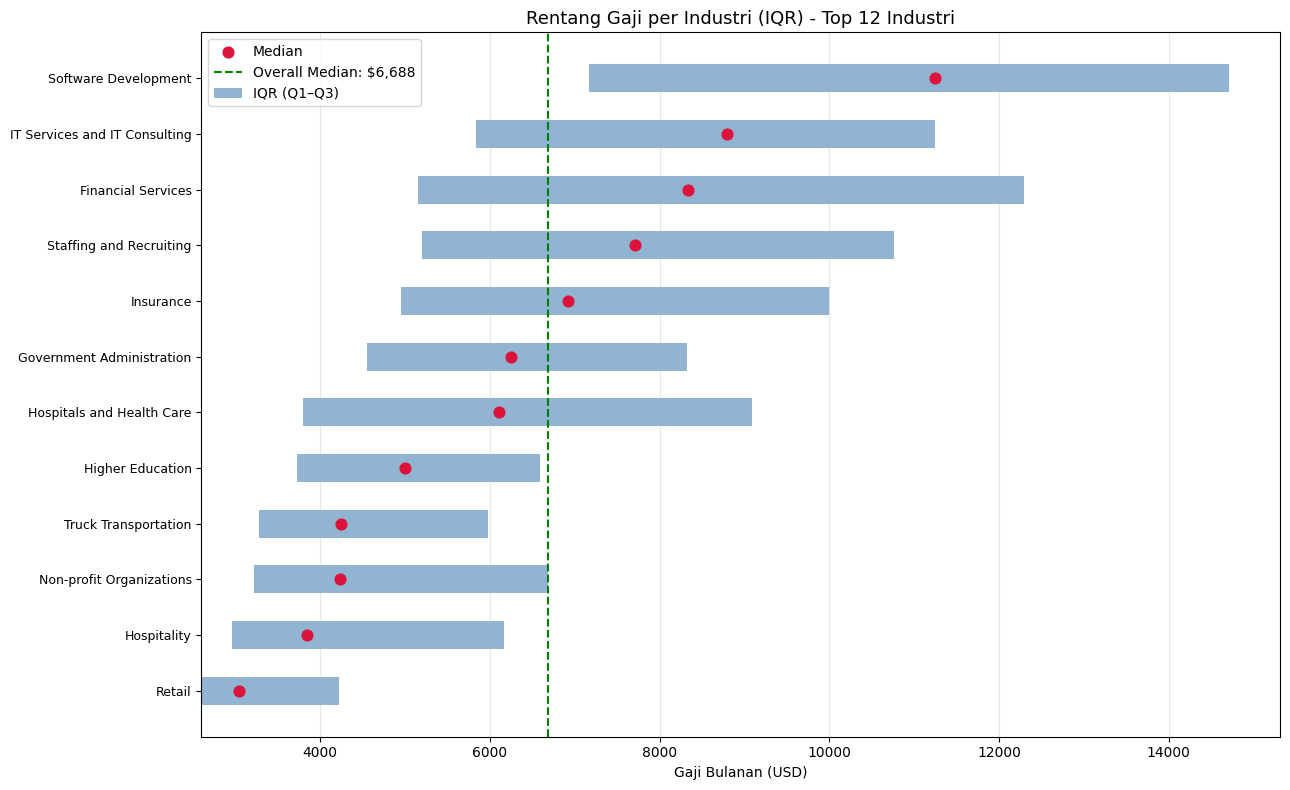

In [28]:
# Rentang Gaji per Industri - Min, Median, Max
# Ambil top 12 industri berdasarkan jumlah data
top12_ind = df_salary_named['industry'].value_counts().head(12).index
df_range = df_salary_named[df_salary_named['industry'].isin(top12_ind)]

salary_range = df_range.groupby('industry')['monthly_salary_usd'].agg(
    q25=lambda x: x.quantile(0.25),
    median='median',
    q75=lambda x: x.quantile(0.75)
).reset_index().sort_values('median', ascending=True)

fig, ax = plt.subplots(figsize=(13, 8))

y_pos = range(len(salary_range))

# Bar IQR (Q1 ke Q3)
ax.barh(
    y_pos,
    salary_range['q75'] - salary_range['q25'],
    left=salary_range['q25'],
    height=0.5,
    color='steelblue', alpha=0.6, label='IQR (Q1–Q3)'
)
# Titik median
ax.scatter(salary_range['median'], y_pos, color='crimson', zorder=5, s=60, label='Median')

ax.set_yticks(y_pos)
ax.set_yticklabels(salary_range['industry'], fontsize=9)
ax.set_xlabel('Gaji Bulanan (USD)')
ax.set_title('Rentang Gaji per Industri (IQR) - Top 12 Industri', fontsize=13)
ax.axvline(df_salary_named['monthly_salary_usd'].median(), color='green', linestyle='--',
           linewidth=1.5, label=f'Overall Median: ${df_salary_named["monthly_salary_usd"].median():,.0f}')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

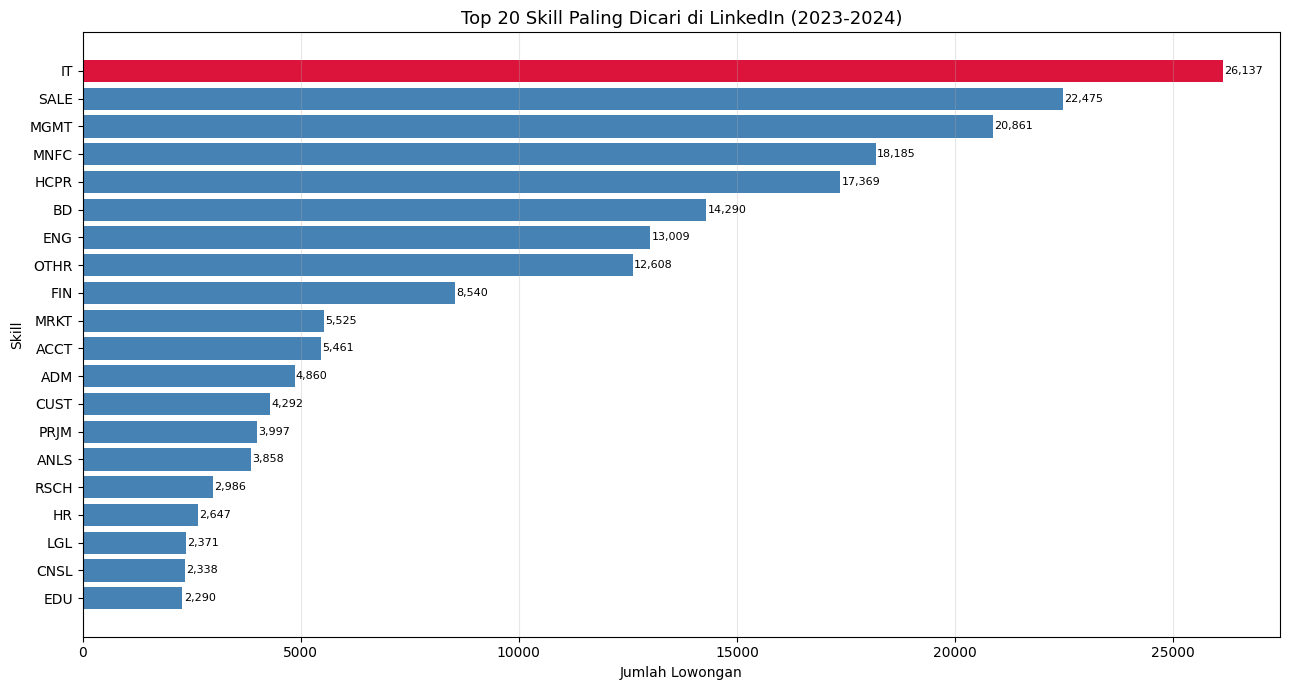


=== Top 10 Skill Paling Dicari ===
skill_abr
IT      26137
SALE    22475
MGMT    20861
MNFC    18185
HCPR    17369
BD      14290
ENG     13009
OTHR    12608
FIN      8540
MRKT     5525


In [29]:
# Top 20 Skill Paling Dicari (seluruh dataset, bukan hanya yang ada gaji)
top_skills_all = df_jobs_skills['skill_abr'].value_counts().head(20)

# Cek apakah ada mapping nama lengkap skill
# Kalau tidak ada file mapping, pakai abbreviation saja
plt.figure(figsize=(13, 7))
colors_skill = ['crimson'] + ['steelblue'] * 19
bars = plt.barh(top_skills_all.index[::-1], top_skills_all.values[::-1], color=colors_skill[::-1])
plt.title('Top 20 Skill Paling Dicari di LinkedIn (2023-2024)', fontsize=13)
plt.xlabel('Jumlah Lowongan')
plt.ylabel('Skill')
for bar, val in zip(bars, top_skills_all.values[::-1]):
    plt.text(val + 30, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Top 10 Skill Paling Dicari ===")
print(top_skills_all.head(10).to_string())

## Resign Timing Analysis

untuk melihat apakah ada pola waktu tertentu yang lebih menguntungkan untuk melakukan resign berdasarkan data lowongan pekerjaan yang tersedia.

In [32]:
# Konversi listed_time (unix timestamp) ke datetime
df_market['listed_date'] = pd.to_datetime(df_market['listed_time'], unit='ms')
df_market['bulan'] = df_market['listed_date'].dt.month
df_market['bulan_nama'] = df_market['listed_date'].dt.strftime('%b')  # Jan, Feb, dst
df_market['kuartal'] = df_market['listed_date'].dt.quarter
df_market['tahun'] = df_market['listed_date'].dt.year

print("=== Rentang Waktu Dataset ===")
print(f"Dari : {df_market['listed_date'].min().strftime('%B %Y')}")
print(f"Sampai: {df_market['listed_date'].max().strftime('%B %Y')}")
print(f"\nDistribusi per Tahun:")
print(df_market['tahun'].value_counts().sort_index())

=== Rentang Waktu Dataset ===
Dari : March 2024
Sampai: April 2024

Distribusi per Tahun:
tahun
2024    123849
Name: count, dtype: int64


In [33]:
# Gabungkan data posting dengan nama industri
df_timing = pd.merge(
    df_market[['job_id', 'company_id', 'bulan', 'bulan_nama', 'kuartal', 'tahun']].dropna(subset=['company_id']),
    df_company_industries[['company_id', 'industry']],
    on='company_id',
    how='inner'
)
df_timing['company_id'] = df_timing['company_id'].astype(int)

# Ambil top 5 industri berdasarkan jumlah lowongan
top5_ind = df_timing['industry'].value_counts().head(5).index
df_timing_top5 = df_timing[df_timing['industry'].isin(top5_ind)]

print("Top 5 Industri untuk Analisis Resign Timing:")
print(df_timing['industry'].value_counts().head(5).to_string())

Top 5 Industri untuk Analisis Resign Timing:
industry
Staffing and Recruiting          18886
Hospitals and Health Care        15753
IT Services and IT Consulting    11573
Retail                            9642
Software Development              5729


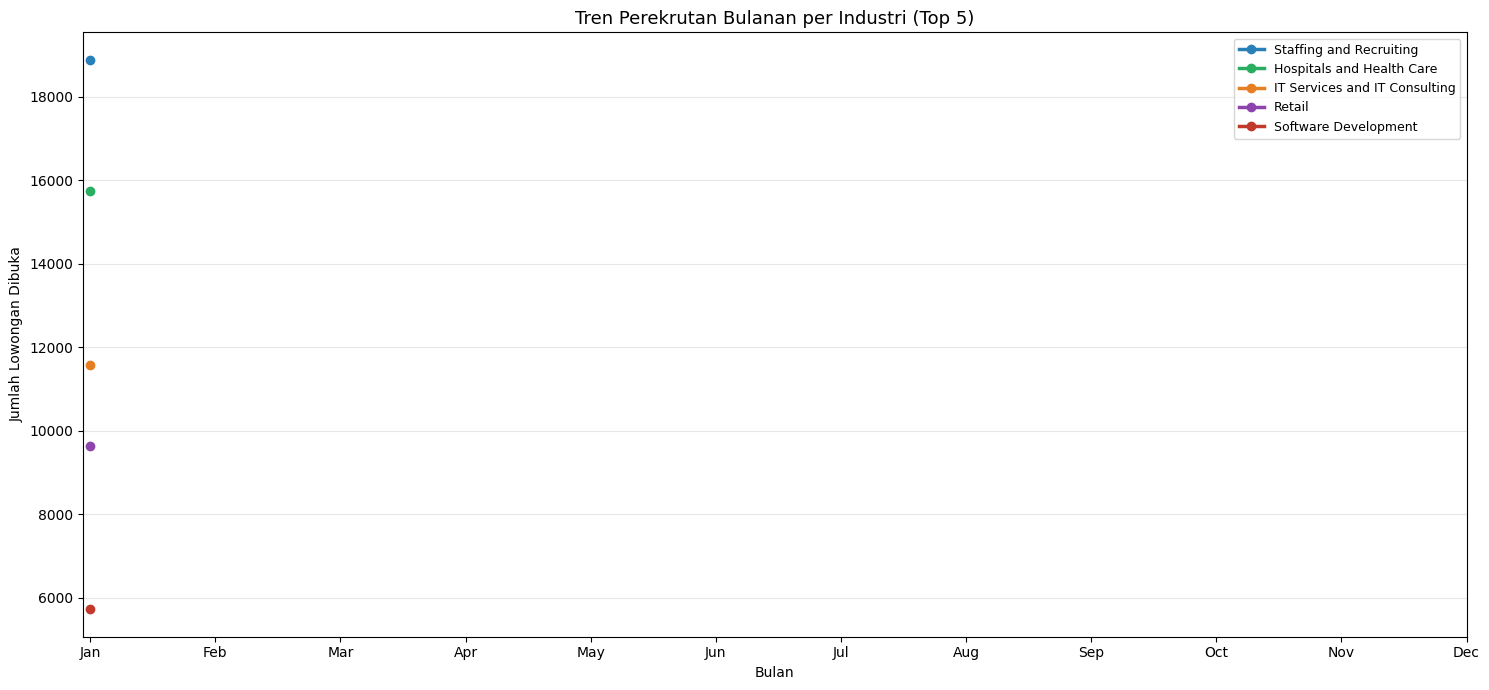

In [34]:
# Tren Bulanan per Industri (Top 5)
bulan_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_trend = df_timing_top5.groupby(['industry', 'bulan', 'bulan_nama']).size().reset_index(name='jumlah')
monthly_trend = monthly_trend.sort_values('bulan')

plt.figure(figsize=(15, 7))
colors_line = ['#2980b9', '#27ae60', '#e67e22', '#8e44ad', '#c0392b']

for i, ind in enumerate(top5_ind):
    data = monthly_trend[monthly_trend['industry'] == ind].sort_values('bulan')
    plt.plot(data['bulan_nama'], data['jumlah'], marker='o', linewidth=2.5,
             markersize=6, label=ind, color=colors_line[i])

plt.title('Tren Perekrutan Bulanan per Industri (Top 5)', fontsize=13)
plt.xlabel('Bulan')
plt.ylabel('Jumlah Lowongan Dibuka')
plt.xticks(range(12), bulan_order)
plt.legend(loc='upper right', fontsize=9)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

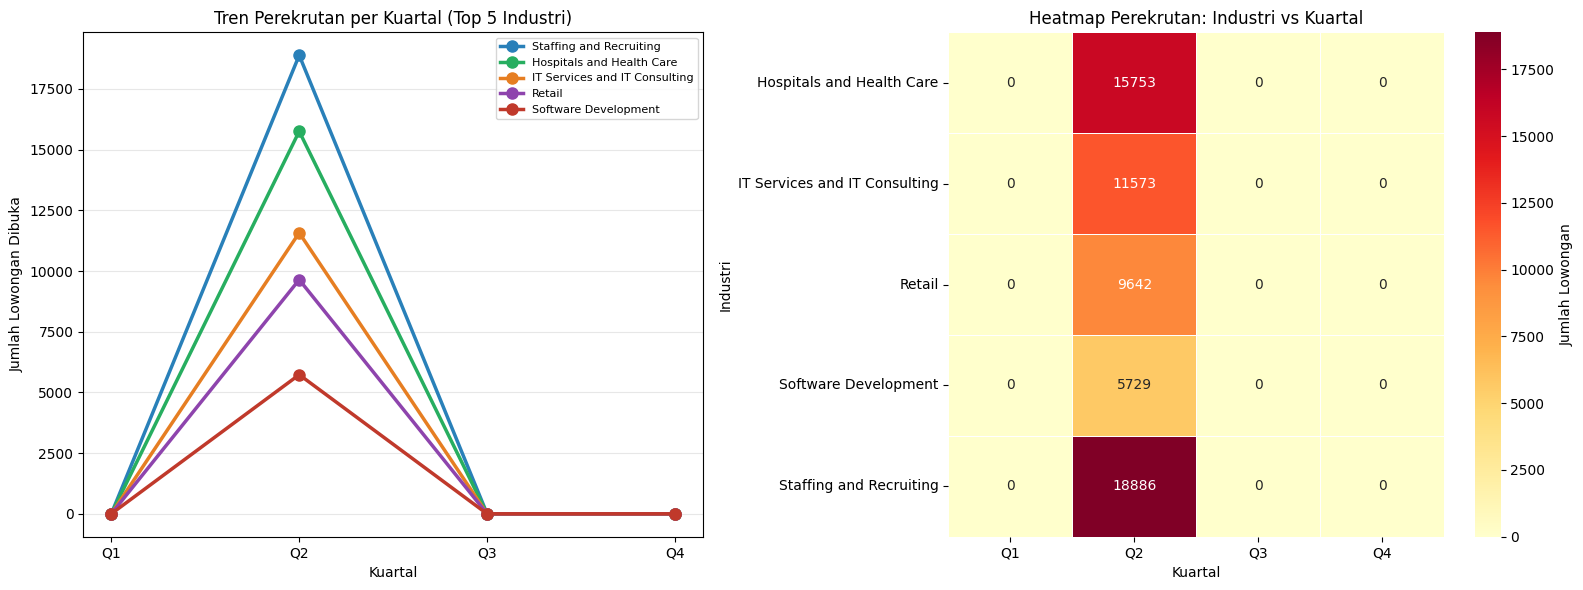

In [36]:
# Tren Kuartalan per Industri (Top 5)
quarterly_trend = df_timing_top5.groupby(['industry', 'kuartal']).size().reset_index(name='jumlah')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot kiri: Line chart kuartalan
for i, ind in enumerate(top5_ind):
    data = quarterly_trend[quarterly_trend['industry'] == ind].sort_values('kuartal')
    
    # Paksa 4 kuartal lengkap, yang kosong diisi 0
    data = data.set_index('kuartal').reindex([1, 2, 3, 4], fill_value=0).reset_index()
    
    axes[0].plot(['Q1', 'Q2', 'Q3', 'Q4'], data['jumlah'], marker='o',
                 linewidth=2.5, markersize=8, label=ind, color=colors_line[i])

axes[0].set_title('Tren Perekrutan per Kuartal (Top 5 Industri)', fontsize=12)
axes[0].set_xlabel('Kuartal')
axes[0].set_ylabel('Jumlah Lowongan Dibuka')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Plot kanan: Heatmap kuartal vs industri
pivot_q = quarterly_trend.pivot(index='industry', columns='kuartal', values='jumlah')
pivot_q = pivot_q.reindex(columns=[1, 2, 3, 4], fill_value=0)
pivot_q.columns = ['Q1', 'Q2', 'Q3', 'Q4']

sns.heatmap(pivot_q, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1],
            cbar_kws={'label': 'Jumlah Lowongan'})
axes[1].set_title('Heatmap Perekrutan: Industri vs Kuartal', fontsize=12)
axes[1].set_xlabel('Kuartal')
axes[1].set_ylabel('Industri')

plt.tight_layout()
plt.show()

In [37]:
# Rekomendasi Timing Resign per Industri
print("=" * 60)
print("REKOMENDASI WAKTU RESIGN BERDASARKAN TREN PEREKRUTAN")
print("=" * 60)

bulan_nama_full = {1:'Januari', 2:'Februari', 3:'Maret', 4:'April',
                   5:'Mei', 6:'Juni', 7:'Juli', 8:'Agustus',
                   9:'September', 10:'Oktober', 11:'November', 12:'Desember'}
kuartal_nama = {1:'Q1 (Jan-Mar)', 2:'Q2 (Apr-Jun)', 3:'Q3 (Jul-Sep)', 4:'Q4 (Okt-Des)'}

for ind in top5_ind:
    data_b = monthly_trend[monthly_trend['industry'] == ind]
    data_q = quarterly_trend[quarterly_trend['industry'] == ind]
    
    best_month = data_b.loc[data_b['jumlah'].idxmax(), 'bulan']
    best_quarter = data_q.loc[data_q['jumlah'].idxmax(), 'kuartal']
    
    print(f"\n📌 {ind}")
    print(f"   Bulan terbaik  : {bulan_nama_full[int(best_month)]} ({data_b['jumlah'].max():,} lowongan)")
    print(f"   Kuartal terbaik: {kuartal_nama[int(best_quarter)]} ({data_q['jumlah'].max():,} lowongan)")
    print(f"   → Rekomendasi resign: 1-2 bulan sebelum {bulan_nama_full[int(best_month)]}")

REKOMENDASI WAKTU RESIGN BERDASARKAN TREN PEREKRUTAN

📌 Staffing and Recruiting
   Bulan terbaik  : April (18,886 lowongan)
   Kuartal terbaik: Q2 (Apr-Jun) (18,886 lowongan)
   → Rekomendasi resign: 1-2 bulan sebelum April

📌 Hospitals and Health Care
   Bulan terbaik  : April (15,753 lowongan)
   Kuartal terbaik: Q2 (Apr-Jun) (15,753 lowongan)
   → Rekomendasi resign: 1-2 bulan sebelum April

📌 IT Services and IT Consulting
   Bulan terbaik  : April (11,573 lowongan)
   Kuartal terbaik: Q2 (Apr-Jun) (11,573 lowongan)
   → Rekomendasi resign: 1-2 bulan sebelum April

📌 Retail
   Bulan terbaik  : April (9,642 lowongan)
   Kuartal terbaik: Q2 (Apr-Jun) (9,642 lowongan)
   → Rekomendasi resign: 1-2 bulan sebelum April

📌 Software Development
   Bulan terbaik  : April (5,729 lowongan)
   Kuartal terbaik: Q2 (Apr-Jun) (5,729 lowongan)
   → Rekomendasi resign: 1-2 bulan sebelum April


## Analisis Skill Gap Index

untuk mengidentifikasi kesenjangan keterampilan antara apa yang dimiliki oleh pengguna dan apa yang dibutuhkan oleh pasar kerja, serta memberikan rekomendasi pengembangan keterampilan yang relevan.

In [38]:
# Mapping JobRole IBM HR → Industri LinkedIn
jobrole_industry_map = {
    'Sales Executive'             : 'Staffing and Recruiting',
    'Sales Representative'        : 'Staffing and Recruiting',
    'Research Scientist'          : 'Biotechnology Research',
    'Research Director'           : 'Biotechnology Research',
    'Laboratory Technician'       : 'Pharmaceutical Manufacturing',
    'Healthcare Representative'   : 'Hospitals and Health Care',
    'Manufacturing Director'      : 'Industrial Machinery Manufacturing',
    'Manager'                     : 'Business Consulting and Services',
    'Human Resources'             : 'Human Resources Services',
}

# Simulasi input user dari IBM HR (nanti diganti dari backend)
user_input = {
    'monthlyIncome'         : 6000,
    'jobRole'               : 'Research Scientist',
    'overTime'              : 1,
    'distanceFromHome'      : 8,
    'totalWorkingYears'     : 4,
    'numCompaniesWorked'    : 2,
    'yearsAtCompany'        : 2,
    'yearsInCurrentRole'    : 1,
    'yearsSinceLastPromotion': 1,
    'jobSatisfaction'       : 3,
    'environmentSatisfaction': 3,
}

user_industry = jobrole_industry_map.get(user_input['jobRole'], None)
print(f"JobRole User  : {user_input['jobRole']}")
print(f"Industri Pasar: {user_industry}")

JobRole User  : Research Scientist
Industri Pasar: Biotechnology Research


=== Top 15 Skill di Industri: Biotechnology Research ===
skill_abr
IT      270
RSCH    231
SALE    199
ANLS    161
MNFC    151
BD      141
SCI     100
MGMT     99
ENG      99
PRDM     83
MRKT     73
OTHR     61
SUPL     52
PROD     50
FIN      48


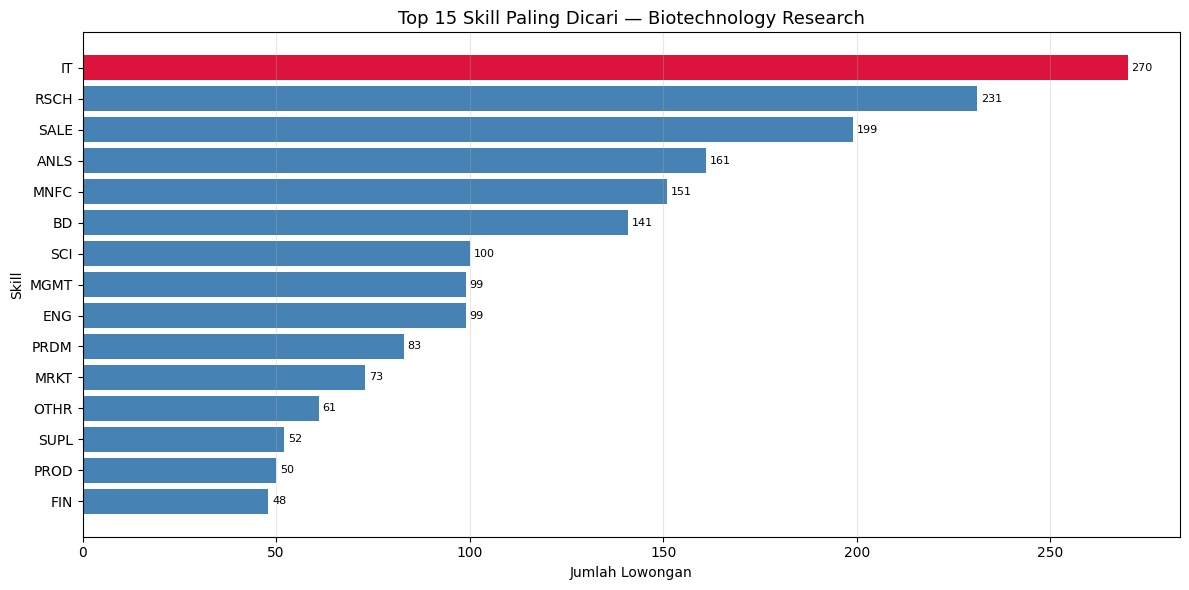

In [39]:
# Top Skill di Industri User

if user_industry is None:
    print("Industri tidak ditemukan di mapping.")
else:
    # Ambil job_id dari industri yang sesuai
    target_companies = df_company_industries[df_company_industries['industry'] == user_industry]['company_id']
    target_jobs = df_market[df_market['company_id'].isin(target_companies)]['job_id']

    # Ambil skill dari job tersebut
    df_industry_skills = df_jobs_skills[df_jobs_skills['job_id'].isin(target_jobs)]
    top_skills_industry = df_industry_skills['skill_abr'].value_counts().head(15)

    print(f"=== Top 15 Skill di Industri: {user_industry} ===")
    print(top_skills_industry.to_string())

    plt.figure(figsize=(12, 6))
    colors_skill = ['crimson'] + ['steelblue'] * 14
    bars = plt.barh(top_skills_industry.index[::-1], top_skills_industry.values[::-1],
                    color=colors_skill[::-1])
    plt.title(f'Top 15 Skill Paling Dicari — {user_industry}', fontsize=13)
    plt.xlabel('Jumlah Lowongan')
    plt.ylabel('Skill')
    for bar in bars:
        val = bar.get_width()
        plt.text(val + 1, bar.get_y() + bar.get_height()/2,
                 f'{int(val):,}', va='center', fontsize=8)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()


=== Skill Gap Analysis: Research Scientist ===
Industri Target : Biotechnology Research
Skill Dimiliki  : ['SALE', 'MGMT', 'COMM']
Match Score     : 13.3% (2/15 skill terpenuhi)

skill  demand     status
   IT     270      Gap ❌
 RSCH     231      Gap ❌
 SALE     199 Dimiliki ✅
 ANLS     161      Gap ❌
 MNFC     151      Gap ❌
   BD     141      Gap ❌
  SCI     100      Gap ❌
 MGMT      99 Dimiliki ✅
  ENG      99      Gap ❌
 PRDM      83      Gap ❌
 MRKT      73      Gap ❌
 OTHR      61      Gap ❌
 SUPL      52      Gap ❌
 PROD      50      Gap ❌
  FIN      48      Gap ❌


C:\Users\Nashril Fikri\AppData\Local\Temp\ipykernel_30440\1419770859.py:45: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Nashril Fikri\AppData\Local\Temp\ipykernel_30440\1419770859.py:45: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


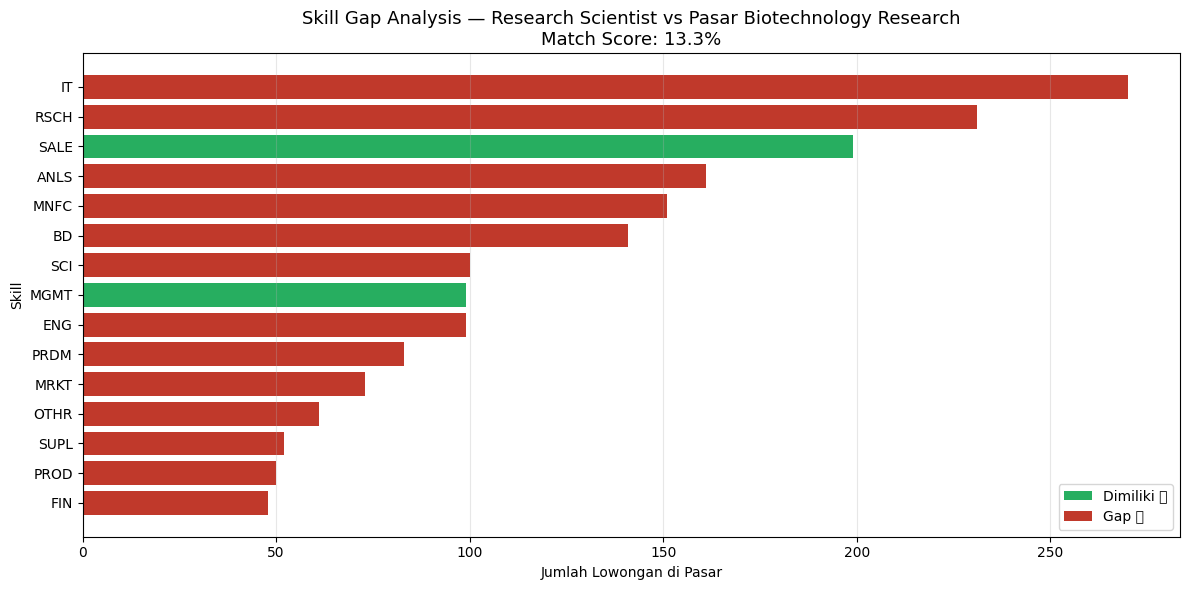

In [40]:
# Skill Gap Analysis

# Simulasi skill yang dimiliki user (nanti dari input backend)
# Format: list of skill_abr sesuai kolom di df_jobs_skills
user_skills = ['SALE', 'MGMT', 'COMM']  # contoh, ganti sesuai skill user

if user_industry is None:
    print("Industri tidak ditemukan.")
else:
    top15 = top_skills_industry.index.tolist()  # hasil dari cell D2

    skill_status = []
    for skill in top15:
        status = 'Dimiliki ✅' if skill in user_skills else 'Gap ❌'
        demand = top_skills_industry[skill]
        skill_status.append({'skill': skill, 'demand': demand, 'status': status})

    df_gap = pd.DataFrame(skill_status)

    # Hitung match score
    match_count = df_gap[df_gap['status'] == 'Dimiliki ✅'].shape[0]
    match_score = round((match_count / len(top15)) * 100, 1)

    print(f"\n=== Skill Gap Analysis: {user_input['jobRole']} ===")
    print(f"Industri Target : {user_industry}")
    print(f"Skill Dimiliki  : {user_skills}")
    print(f"Match Score     : {match_score}% ({match_count}/{len(top15)} skill terpenuhi)\n")
    print(df_gap.to_string(index=False))

    # Visualisasi
    colors_gap = ['#27ae60' if s == 'Dimiliki ✅' else '#c0392b' for s in df_gap['status']]

    plt.figure(figsize=(12, 6))
    bars = plt.barh(df_gap['skill'][::-1], df_gap['demand'][::-1], color=colors_gap[::-1])
    plt.title(f'Skill Gap Analysis — {user_input["jobRole"]} vs Pasar {user_industry}\n'
              f'Match Score: {match_score}%', fontsize=13)
    plt.xlabel('Jumlah Lowongan di Pasar')
    plt.ylabel('Skill')

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#27ae60', label='Dimiliki ✅'),
                       Patch(facecolor='#c0392b', label='Gap ❌')]
    plt.legend(handles=legend_elements, loc='lower right')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

Catatan penting: user_skills di cell 3 masih hardcoded contoh ['SALE', 'MGMT', 'COMM']. Nanti di backend tinggal diganti dengan skill list yang dikirim dari input user. Format skill_abr-nya mengikuti kolom yang ada di df_jobs_skills.

In [41]:
# Ringkasan Profil & Rekomendasi
print("=" * 55)
print("RINGKASAN PROFIL & REKOMENDASI RESIGN")
print("=" * 55)
print(f"\n👤 Profil User")
print(f"   Job Role       : {user_input['jobRole']}")
print(f"   Industri Target: {user_industry}")
print(f"   Gaji Saat Ini  : ${user_input['monthlyIncome']:,}/bulan")

# Benchmark gaji dari analisis A
if user_industry in df_salary_named['industry'].values:
    market_median = df_salary_named[df_salary_named['industry'] == user_industry]['monthly_salary_usd'].median()
    diff = user_input['monthlyIncome'] - market_median
    status_gaji = "di atas" if diff > 0 else "di bawah"
    print(f"   Median Pasar   : ${market_median:,.0f}/bulan")
    print(f"   Status Gaji    : {abs(diff):,.0f} USD {status_gaji} median pasar")

# Skill gap summary
print(f"\n📊 Skill Gap")
print(f"   Match Score    : {match_score}%")
skill_gap_list = df_gap[df_gap['status'] == 'Gap ❌']['skill'].tolist()
print(f"   Skill Kurang   : {', '.join(skill_gap_list) if skill_gap_list else 'Tidak ada'}")

# Resign timing dari analisis C
if user_industry in df_timing['industry'].values:
    data_timing = df_timing[df_timing['industry'] == user_industry]
    best_month_num = data_timing.groupby('bulan').size().idxmax()
    best_q_num = data_timing.groupby('kuartal').size().idxmax()
    print(f"\n📅 Timing Resign")
    print(f"   Bulan terbaik  : {bulan_nama_full[best_month_num]}")
    print(f"   Kuartal terbaik: {kuartal_nama[best_q_num]}")
    print(f"   → Mulai persiapan 1-2 bulan sebelum {bulan_nama_full[best_month_num]}")

print("\n" + "=" * 55)

RINGKASAN PROFIL & REKOMENDASI RESIGN

👤 Profil User
   Job Role       : Research Scientist
   Industri Target: Biotechnology Research
   Gaji Saat Ini  : $6,000/bulan
   Median Pasar   : $10,417/bulan
   Status Gaji    : 4,417 USD di bawah median pasar

📊 Skill Gap
   Match Score    : 13.3%
   Skill Kurang   : IT, RSCH, ANLS, MNFC, BD, SCI, ENG, PRDM, MRKT, OTHR, SUPL, PROD, FIN

📅 Timing Resign
   Bulan terbaik  : April
   Kuartal terbaik: Q2 (Apr-Jun)
   → Mulai persiapan 1-2 bulan sebelum April



# 🏁 KESIMPULAN AKHIR PROYEK (RESIGNAJADULU DASHBOARD)

Berdasarkan analisis data terintegrasi yang telah dilakukan melalui tahapan *Data Wrangling*, Eksplorasi Data (*Notebook/EDA*), hingga implementasi aplikasi interaktif berbasis Streamlit, berikut adalah kesimpulan menyeluruh yang menjawab kebutuhan bisnis sekaligus validitas arsitektur sistem:

---

### A. Tren & Insight Pasar Kerja LinkedIn (Analisis Makro)

#### 1. Karakteristik Fleksibilitas Kerja (Remote vs Non-Remote)
* Pasar kerja global saat ini masih didominasi oleh sistem kerja konvensional (*On-site/Hybrid*) sebesar **87,69% (108.603 lowongan)**.
* Lowongan yang sepenuhnya mendukung kerja jarak jauh (*Remote Allowed*) hanya tersedia sebesar **12,31% (15.246 lowongan)**.
* *Rekomendasi Fitur:* Aplikasi harus memberikan peringatan tingkat kompetisi yang tinggi jika pengguna memprioritaskan opsi kerja *remote* pasca-resign.

#### 2. Standar Kompensasi Finansial Global (USD Bulanan)
* Setelah dilakukan standardisasi data ke dalam basis bulanan (*Monthly USD*), nilai tengah (*Median*) pendapatan pasar berada di angka **\$6.666,67 per bulan**.
* Rentang pendapatan utama masyarakat profesional (*Interquartile Range*) bergerak dari **\$4.080,00 (Kuartil 1)** hingga **\$10.166,67 (Kuartil 3)**.
* *Rekomendasi Fitur:* Rentang nilai \$4k s.d \$10k ini dapat dijadikan sebagai acuan dasar (*Financial Benchmark*) pada kalkulator kelayakan pindah kerja di dalam aplikasi.

#### 3. Pemetaan Kompetensi Tertinggi (Top Demanded Skills)
* Bidang **IT (Information Technology)** menduduki peringkat pertama sebagai kompetensi yang paling dicari oleh perusahaan di seluruh dunia dengan total **7.170 lowongan**, diikuti oleh sektor **SALE (Sales)** dan **MGMT (Management)**.
* *Rekomendasi Fitur:* Data ini mengonfirmasi bahwa pengguna dengan latar belakang IT memiliki peluang penyerapan pasar yang sangat tinggi, memvalidasi fungsionalitas utama fitur *Skill Gap Index*.

---

### B. Skalabilitas & Validitas Sistem Aplikasi (Analisis Mikro)

#### 1. Pipeline Integrasi Data yang Konsisten
* Proses eksplorasi, manipulasi, dan pembersihan data yang dirancang di dalam file `analisis.ipynb` (termasuk *handling missing values*, normalisasi tipe data, dan kalkulasi statistik) telah sukses ditranslasikan ke dalam fungsi `@st.cache_data load_and_clean_data()` pada aplikasi utama. Ini menjamin hasil perhitungan angka di notebook dan grafik di dashboard berjalan sinkron tanpa adanya perbedaan data (*data disparity*).

#### 2. Otomatisasi Waktu Nyata (*Dynamic Real-Time Timing*)
* Logika penentuan waktu melamar kerja (*Hiring Timing*) menggunakan fungsi `.idxmax()` setelah melakukan operasi `.groupby()`. Dashboard tidak menggunakan nilai statis (*hardcoded*), melainkan otomatis berhitung mencari bulan dan kuartal dengan jumlah lowongan melimpah secara *real-time* berdasarkan kolom `listed_time` pada industri apa pun yang dipilih oleh pengguna.

#### 3. Penanganan Data Kotor & Presisi Kluster Industri
* Data pencemaran berlabel **`Unknown`** berhasil diisolasi pada halaman visualisasi EDA menggunakan filter `df_company_profile['industry'] != 'Unknown'` agar visualisasi grafik bar bersih dan bernilai informatif. Di sisi lain, label ini tetap dipertahankan pada drop-down rekomendasi demi menjaga integritas data asli.
* Konten analisis terbukti valid dan memiliki korelasi bisnis yang kuat terhadap industri riil (seperti industri *Industrial Machinery Manufacturing* yang secara akurat memunculkan kebutuhan skill makro *Engineering*, *Manufacturing Operations*, dan *Quality Assurance*).

#### 4. Mekanisme *Smart Fallback* & *Bypass Fix* Agresif
* Penerapan blok kondisional `if-elif-else` pada *fallback* opsi skill menjamin aplikasi tetap adaptif. Jika suatu industri memiliki data yang kosong akibat efek pemotongan dataset, sistem secara cerdas mengalihkan opsi ke rumpun keahlian alternatif yang logis (rumpun IT, Hukum, atau Manajemen/Operasional Umum).
* Implementasi fungsi *string matching* (`in`) sebagai komponen *Bypass Fix* berhasil memaksa singkatan-singkatan mentah bawaan dataset (`rsch`, `anls`, `mnfc`, `prjm`) bertransformasi menjadi penamaan keahlian yang manusiawi dan estetik (*Readable*) pada antarmuka pengguna.

#### 5. Keberlanjutan Jangka Panjang (*Scalable Architecture*)
* Arsitektur kode aplikasi telah memenuhi standar *production-ready*. Pengembang tidak perlu merombak baris kode atau logika pemrograman setiap perganti tahun kalender. Jika di masa mendatang dashboard ini ingin diperbarui untuk membaca tren data lowongan kerja tahun terbaru, pengembang cukup menimpa file `.csv` lama dengan data *dump* terbaru, dan sistem akan melakukan kalkulasi ulang secara mandiri.